# Kualitas Udara diKabupaten Bangkalan
###1. Business Understanding
#### Tujuan proyek

Proyek ini bertujuan untuk mengamati kondisi dan perubahan konsentrasi beberapa polutan udara di Kabupaten Bangkalan selama satu tahun, yaitu dari 31 Agustus 2025 sampai 30 Agustus 2026, dengan memanfaatkan data citra satelit Sentinel-5P melalui platform openEO Copernicus Data Space.

#### Polutan yang diamati adalah:

- NO₂ (Nitrogen Dioxide)
- CO (Carbon Monoxide)
- SO₂ (Sulfur Dioxide)
- HCHO (Formaldehyde)
- CH₄ (Methane)

Data dihitung secara harian, kemudian digunakan untuk melihat perubahan nilai polutan dari waktu ke waktu melalui analisis time series.

#### Permasalahan

Kualitas udara dapat berubah dari hari ke hari akibat berbagai aktivitas dan kondisi lingkungan. Oleh karena itu, diperlukan pemantauan yang dapat menunjukkan bagaimana konsentrasi polutan berubah selama periode tertentu.

#### Tujuan analisis

Analisis dilakukan untuk:

1. Mengambil data polutan di wilayah Kabupaten Bangkalan.
2. Mengamati perubahan nilai setiap polutan secara harian.
3. Mengetahui nilai minimum, rata-rata, dan maksimum setiap polutan.
4. Mengetahui tanggal ketika nilai polutan mencapai nilai tertinggi dan terendah.
5. Mengidentifikasi pola perubahan polutan selama satu tahun.
6. Menyajikan hasil dalam bentuk grafik time series.
7. Menyimpan hasil pengolahan dalam format CSV

#### Manfaat

Hasil proyek dapat digunakan sebagai informasi awal untuk mengamati pola kualitas udara di Kabupaten Bangkalan dengan bantuan data satelit. Data tersebut dapat membantu melihat periode ketika suatu parameter polutan mengalami peningkatan atau penurunan.

### 2. Data Understanding
#### Sumber data
Data diperoleh menggunakan Sentinel-5P Level-2 melalui Copernicus Data Space Ecosystem dengan openEO.
Wilayah penelitian adalah Kabupaten Bangkalan, Jawa Timur.

#### Periode:
31 Agustus 2025 – 30 Agustus 2026

Data yang digunakan terdiri dari lima parameter:
| Parameter | Nama             | Keterangan umum                                                                       |
| --------- | ---------------- | ------------------------------------------------------------------------------------- |
| NO₂       | Nitrogen Dioxide | Gas yang berkaitan dengan pembakaran dan aktivitas transportasi/industri              |
| CO        | Carbon Monoxide  | Gas hasil pembakaran tidak sempurna                                                   |
| SO₂       | Sulfur Dioxide   | Gas yang berkaitan dengan pembakaran bahan bakar yang mengandung sulfur               |
| HCHO      | Formaldehyde     | Senyawa yang dapat berkaitan dengan proses kimia atmosfer dan berbagai sumber emisi   |
| CH₄       | Methane          | Gas rumah kaca yang dapat berasal dari berbagai sumber alami maupun aktivitas manusia |

Kenapa HCHO tetap digunakan?
HCHO bukan "polutan utama" seperti NO₂ atau CO dalam semua konteks kualitas udara, tetapi merupakan parameter atmosfer yang dapat dipantau oleh Sentinel-5P dan relevan untuk studi komposisi atmosfer.

In [5]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [12]:
import openeo

In [13]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


untuk mengambil dan mengolah data polutan atmosfer di Kabupaten Bangkalan menggunakan Sentinel-5P Level-2 melalui openEO dengan periode pengamatan 31 Agustus 2025 sampai 30 Agustus 2026. Pada bagian awal ditentukan AOI (Area of Interest) berupa polygon berdasarkan koordinat wilayah penelitian, kemudian diambil lima parameter atmosfer yaitu NO₂, CO, SO₂, HCHO, dan CH₄ menggunakan load_collection(). Selanjutnya, data setiap parameter diagregasi berdasarkan waktu menggunakan aggregate_temporal_period() dengan metode rata-rata (mean) dan periode harian (day) agar diperoleh satu nilai rata-rata setiap hari. Setelah itu, dilakukan agregasi spasial menggunakan aggregate_spatial() dengan metode rata-rata berdasarkan AOI, sehingga diperoleh nilai rata-rata masing-masing parameter untuk seluruh wilayah penelitian pada setiap harinya. Hasil pengolahan ini kemudian dapat digunakan sebagai data time series harian untuk menganalisis perubahan nilai polutan di Kabupaten Bangkalan selama satu tahun.

In [14]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.09, -6.89],
            [112.68, -6.89],
            [112.68, -7.20],
            [113.09, -7.20],
            [113.09, -6.89]
        ]
    ]
}

# 2. MENGAMBIL DATA NO2

s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-30"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["NO2"]
)

# 3. MENGAMBIL DATA CO

s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-30"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CO"]
)

# 4. MENGAMBIL DATA SO2

s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-30"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["SO2"]
)

# 5. MENGAMBIL DATA HCHO

s5HCHO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-30"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["HCHO"]
)

# 6. MENGAMBIL DATA CH4

s5CH4 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-30"],
    spatial_extent={
        "west": 112.68,
        "south": -7.20,
        "east": 113.09,
        "north": -6.89
    },
    bands=["CH4"]
)

# 7. AGREGASI DATA PER HARI

s5p_NO2_daily = s5NO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_CO_daily = s5CO.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_SO2_daily = s5SO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_HCHO_daily = s5HCHO.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_CH4_daily = s5CH4.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# 8. AGREGASI SPASIAL

s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

s5p_HCHO_aoi = s5p_HCHO_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

s5p_CH4_aoi = s5p_CH4_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

Setiap data yang telah melalui proses agregasi temporal dan spasial kemudian diproses menggunakan execute_batch() dan disimpan dalam format NetCDF (.nc). Lima file yang dihasilkan yaitu NO2_Bangkalan.nc, CO_Bangkalan.nc, SO2_Bangkalan.nc, HCHO_Bangkalan.nc, dan CH4_Bangkalan.nc. Penggunaan batch job memungkinkan proses pengolahan data dilakukan di server openEO sehingga data hasil pengolahan dapat disimpan dan digunakan untuk tahap selanjutnya, yaitu membaca file NetCDF, mengubahnya menjadi CSV, melakukan pengecekan kualitas data, serta menganalisis perubahan nilai polutan secara harian.

In [18]:
# 9. MENJALANKAN BATCH JOB

job_NO2 = s5p_NO2_aoi.execute_batch(
    title="NO2 di Kabupaten Bangkalan",
    outputfile="NO2_Bangkalan.nc"
)

job_CO = s5p_CO_aoi.execute_batch(
    title="CO di Kabupaten Bangkalan",
    outputfile="CO_Bangkalan.nc"
)

job_SO2 = s5p_SO2_aoi.execute_batch(
    title="SO2 di Kabupaten Bangkalan",
    outputfile="SO2_Bangkalan.nc"
)

job_HCHO = s5p_HCHO_aoi.execute_batch(
    title="HCHO di Kabupaten Bangkalan",
    outputfile="HCHO_Bangkalan.nc"
)

job_CH4 = s5p_CH4_aoi.execute_batch(
    title="CH4 di Kabupaten Bangkalan",
    outputfile="CH4_Bangkalan.nc"
)

0:00:00 Job 'j-2608301458564ca1a34dc57e63e7530d': send 'start'
0:00:02 Job 'j-2608301458564ca1a34dc57e63e7530d': created (progress 0%)
0:00:08 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:00:14 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:00:22 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:00:32 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:00:45 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:01:00 Job 'j-2608301458564ca1a34dc57e63e7530d': queued (progress 0%)
0:01:20 Job 'j-2608301458564ca1a34dc57e63e7530d': running (progress N/A)
0:01:44 Job 'j-2608301458564ca1a34dc57e63e7530d': running (progress N/A)
0:02:14 Job 'j-2608301458564ca1a34dc57e63e7530d': running (progress N/A)
0:02:51 Job 'j-2608301458564ca1a34dc57e63e7530d': running (progress N/A)
0:03:38 Job 'j-2608301458564ca1a34dc57e63e7530d': finished (progress 100%)
0:00:00 Job 'j-2608301502404053b54d11ecc714e233': send 'start'
0:00:02 J

In [19]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.5 MB/s eta 0:00:00


untuk membuka dan membaca lima file hasil pengolahan Sentinel-5P dalam format NetCDF (.nc) menggunakan library netCDF4. File NO2_Bangkalan.nc, CO_Bangkalan.nc, SO2_Bangkalan.nc, HCHO_Bangkalan.nc, dan CH4_Bangkalan.nc masing-masing dibuka dan disimpan ke dalam variabel dsNO2, dsCO, dsSO2, dsHCHO, dan dsCH4. Library numpy digunakan untuk membantu pengolahan data numerik, sedangkan pandas nantinya digunakan untuk mengubah data hasil pembacaan menjadi tabel atau DataFrame sehingga dapat diolah dan disimpan dalam format CSV. Dengan cell ini, data NetCDF yang sebelumnya dihasilkan melalui batch job sudah siap untuk masuk ke tahap ekstraksi nilai polutan dan waktu, kemudian dikonversi menjadi data time series harian.

In [20]:
import netCDF4
import numpy as np
import pandas as pd

dsNO2 = netCDF4.Dataset("NO2_Bangkalan.nc")
dsCO = netCDF4.Dataset("CO_Bangkalan.nc")
dsSO2 = netCDF4.Dataset("SO2_Bangkalan.nc")
dsHCHO = netCDF4.Dataset("HCHO_Bangkalan.nc")
dsCH4 = netCDF4.Dataset("CH4_Bangkalan.nc")

Perintah dsCO.variables.keys() menampilkan daftar nama variabel yang tersedia di dalam file, seperti variabel waktu (t) dan variabel nilai polutan (CO). Pemeriksaan ini dilakukan untuk memastikan bahwa struktur dan nama variabel dalam file sudah sesuai sebelum data diekstrak dan dikonversi ke format CSV.

In [23]:
print("📦 Variabel dalam file:")
print(dsCO.variables.keys())

📦 Variabel dalam file:
dict_keys(['t', 'CO', 'lat', 'lon', 'feature_names'])


untuk mengambil nilai NO₂ dan informasi waktu dari file NetCDF, kemudian mengubahnya menjadi data time series dalam format CSV. Nilai NO₂ diambil dari variabel NO2, sedangkan waktu pengamatan diambil dari variabel t. Selanjutnya, satuan waktu pada file NetCDF digunakan oleh netCDF4.num2date() untuk mengubah data waktu menjadi format tanggal yang dapat dibaca, kemudian setiap tanggal diubah menjadi format YYYY-MM-DD. Nilai NO₂ dan tanggal tersebut disusun menjadi sebuah DataFrame dengan kolom date dan NO2, lalu disimpan sebagai file NO2_Bangkalan_timeseries_terkini.csv.

In [24]:
no2 = dsNO2.variables["NO2"][:].squeeze()
timeNO2 = dsNO2.variables["t"][:]

try:
    time_units = dsNO2.variables["t"].units
    dates = netCDF4.num2date(timeNO2, units=time_units)
except Exception:
    dates = timeNO2

new_dates = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

dfNO2 = pd.DataFrame({
    "date": new_dates,
    "NO2": no2
})

dfNO2.to_csv(
    "NO2_Bangkalan_timeseries_terkini.csv",
    index=False
)

print("✅ CSV NO2 Bangkalan berhasil dibuat")

✅ CSV NO2 Bangkalan berhasil dibuat


In [25]:
co = dsCO.variables["CO"][:].squeeze()
timeCO = dsCO.variables["t"][:]

try:
    time_units = dsCO.variables["t"].units
    dates = netCDF4.num2date(timeCO, units=time_units)
except Exception:
    dates = timeCO

new_dates = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

dfCO = pd.DataFrame({
    "date": new_dates,
    "CO": co
})

dfCO.to_csv(
    "CO_Bangkalan_timeseries_terkini.csv",
    index=False
)

print("✅ CSV CO Bangkalan berhasil dibuat")

✅ CSV CO Bangkalan berhasil dibuat


In [26]:
so2 = dsSO2.variables["SO2"][:].squeeze()
timeSO2 = dsSO2.variables["t"][:]

try:
    time_units = dsSO2.variables["t"].units
    dates = netCDF4.num2date(timeSO2, units=time_units)
except Exception:
    dates = timeSO2

new_dates = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

dfSO2 = pd.DataFrame({
    "date": new_dates,
    "SO2": so2
})

dfSO2.to_csv(
    "SO2_Bangkalan_timeseries_terkini.csv",
    index=False
)

print("✅ CSV SO2 Bangkalan berhasil dibuat")

✅ CSV SO2 Bangkalan berhasil dibuat


In [27]:
hcho = dsHCHO.variables["HCHO"][:].squeeze()
timeHCHO = dsHCHO.variables["t"][:]

try:
    time_units = dsHCHO.variables["t"].units
    dates = netCDF4.num2date(timeHCHO, units=time_units)
except Exception:
    dates = timeHCHO

new_dates = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

dfHCHO = pd.DataFrame({
    "date": new_dates,
    "HCHO": hcho
})

dfHCHO.to_csv(
    "HCHO_Bangkalan_timeseries_terkini.csv",
    index=False
)

print("✅ CSV HCHO Bangkalan berhasil dibuat")

✅ CSV HCHO Bangkalan berhasil dibuat


In [28]:
ch4 = dsCH4.variables["CH4"][:].squeeze()
timeCH4 = dsCH4.variables["t"][:]

try:
    time_units = dsCH4.variables["t"].units
    dates = netCDF4.num2date(timeCH4, units=time_units)
except Exception:
    dates = timeCH4

new_dates = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

dfCH4 = pd.DataFrame({
    "date": new_dates,
    "CH4": ch4
})

dfCH4.to_csv(
    "CH4_Bangkalan_timeseries_terkini.csv",
    index=False
)

print("✅ CSV CH4 Bangkalan berhasil dibuat")

✅ CSV CH4 Bangkalan berhasil dibuat


digunakan untuk menggabungkan lima file CSV data polutan Kabupaten Bangkalan ke dalam satu file ZIP agar lebih mudah disimpan dan diunduh.

In [29]:
import zipfile
from google.colab import files

nama_file = [
    "NO2_Bangkalan_timeseries_terkini.csv",
    "CO_Bangkalan_timeseries_terkini.csv",
    "SO2_Bangkalan_timeseries_terkini.csv",
    "HCHO_Bangkalan_timeseries_terkini.csv",
    "CH4_Bangkalan_timeseries_terkini.csv"
]

with zipfile.ZipFile("Data_Polutan_Bangkalan.zip", "w") as zip_file:
    for file in nama_file:
        zip_file.write(file)

files.download("Data_Polutan_Bangkalan.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

untuk menggabungkan, menganalisis, dan memvisualisasikan data time series lima parameter atmosfer di Kabupaten Bangkalan selama periode 31 Agustus 2025 sampai 30 Agustus 2026. Pertama, kelima file CSV NO₂, CO, SO₂, HCHO, dan CH₄ dibaca menggunakan pandas, kemudian seluruh data digabungkan berdasarkan kolom date sehingga setiap tanggal memiliki nilai dari masing-masing parameter. Kolom tanggal diubah ke format datetime dan data diurutkan berdasarkan waktu agar urutan pengamatan sesuai secara kronologis. Selanjutnya, ditampilkan beberapa data awal, jumlah data, serta statistik deskriptif untuk mengetahui karakteristik dasar dataset. Setelah itu, matplotlib digunakan untuk membuat grafik time series secara terpisah untuk NO₂, CO, SO₂, HCHO, dan CH₄, dengan tanggal sebagai sumbu X dan nilai masing-masing parameter sebagai sumbu Y. Grafik tersebut digunakan untuk melihat pola perubahan, peningkatan, dan penurunan nilai setiap parameter dari hari ke hari selama satu tahun, sehingga dapat membantu mengidentifikasi periode ketika nilai suatu parameter relatif tinggi atau rendah di Kabupaten Bangkalan.

Data Time Series Polutan Kabupaten Bangkalan:
        date       NO2        CO           SO2      HCHO          CH4
0 2025-09-03  0.000015  0.024309  3.296046e-05  0.000077  1886.999237
1 2025-09-04  0.000018  0.027419  1.527754e-05  0.000103  1843.322510
2 2025-09-05  0.000018  0.028849  3.177223e-06  0.000137  1845.148560
3 2025-09-14  0.000020  0.026743  1.574132e-04  0.000144  1843.491455
4 2025-09-23  0.000033  0.033814  9.436373e-07  0.000213  1854.559692

Jumlah data:
72

Statistik Deskriptif:
                      date        NO2         CO        SO2       HCHO  \
count                   72  72.000000  72.000000  72.000000  72.000000   
mean   2026-05-25 09:40:00   0.000023   0.028962   0.000071   0.000142   
min    2025-09-03 00:00:00   0.000011   0.023296  -0.000123   0.000072   
25%    2026-05-21 00:00:00   0.000018   0.027132   0.000006   0.000117   
50%    2026-06-29 12:00:00   0.000022   0.029098   0.000043   0.000137   
75%    2026-08-04 06:00:00   0.000028   0.030204  

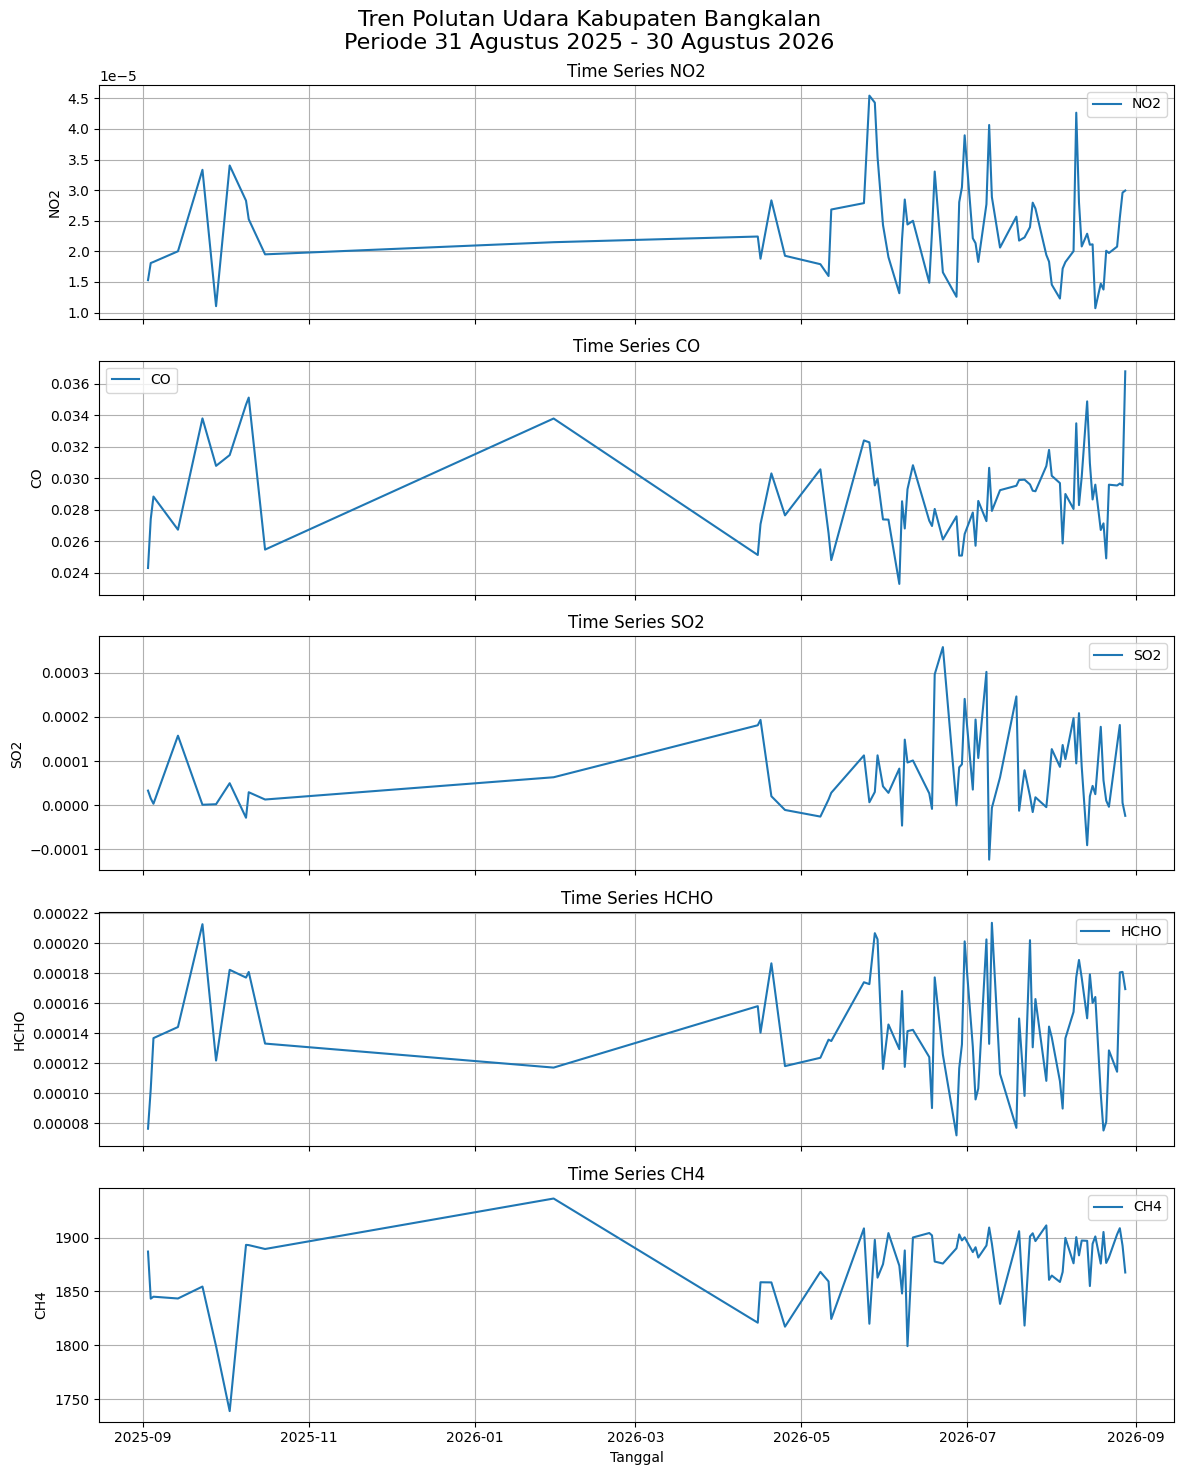

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. MEMBACA DATA CSV

dfNO2 = pd.read_csv("NO2_Bangkalan_timeseries_terkini.csv")
dfCO = pd.read_csv("CO_Bangkalan_timeseries_terkini.csv")
dfSO2 = pd.read_csv("SO2_Bangkalan_timeseries_terkini.csv")
dfHCHO = pd.read_csv("HCHO_Bangkalan_timeseries_terkini.csv")
dfCH4 = pd.read_csv("CH4_Bangkalan_timeseries_terkini.csv")

# 2. MENGGABUNGKAN DATA BERDASARKAN TANGGAL

df = dfNO2.merge(dfCO, on="date")
df = df.merge(dfSO2, on="date")
df = df.merge(dfHCHO, on="date")
df = df.merge(dfCH4, on="date")

# 3. MENGUBAH KOLOM DATE

df["date"] = pd.to_datetime(df["date"])

# 4. MENGURUTKAN DATA BERDASARKAN TANGGAL

df = df.sort_values("date")

# 5. MENAMPILKAN DATA

print("Data Time Series Polutan Kabupaten Bangkalan:")
print(df.head())

print("\nJumlah data:")
print(len(df))

print("\nStatistik Deskriptif:")
print(df.describe())

# 6. DAFTAR POLUTAN

pollutants = ["NO2", "CO", "SO2", "HCHO", "CH4"]

# 7. MEMBUAT GRAFIK TIME SERIES

fig, axes = plt.subplots(
    len(pollutants),
    1,
    figsize=(12, 15),
    sharex=True
)

fig.suptitle(
    "Tren Polutan Udara Kabupaten Bangkalan\n"
    "Periode 31 Agustus 2025 - 30 Agustus 2026",
    fontsize=16
)

# 8. MEMBUAT GRAFIK MASING-MASING POLUTAN

for i in range(len(pollutants)):

    polutan = pollutants[i]

    axes[i].plot(
        df["date"],
        df[polutan],
        label=polutan
    )

    axes[i].set_ylabel(polutan)
    axes[i].set_title("Time Series " + polutan)
    axes[i].legend()
    axes[i].grid(True)

# 9. LABEL SUMBU X

axes[-1].set_xlabel("Tanggal")

# 10. MERAPIKAN TAMPILAN

plt.tight_layout()

plt.subplots_adjust(
    top=0.93
)

plt.show()

In [34]:
from google.colab import files

uploaded = files.upload()

Saving Data_Polutan_Bangkalan.zip to Data_Polutan_Bangkalan (1).zip


In [35]:
import zipfile
import os

nama_zip = "Data_Polutan_Bangkalan.zip"
folder_data = "data_polutan"

with zipfile.ZipFile(nama_zip, "r") as zip_file:
    zip_file.extractall(folder_data)

print("File berhasil diekstrak!")
print(os.listdir(folder_data))

File berhasil diekstrak!
['NO2_Bangkalan_timeseries_terkini.csv', 'CO_Bangkalan_timeseries_terkini.csv', 'SO2_Bangkalan_timeseries_terkini.csv', 'CH4_Bangkalan_timeseries_terkini.csv', 'HCHO_Bangkalan_timeseries_terkini.csv']


In [44]:
import pandas as pd
import zipfile
import os

# 1. NAMA FILE ZIP
nama_zip = "Data_Polutan_Bangkalan.zip"
folder_data = "data_polutan"

# Ekstrak ZIP
with zipfile.ZipFile(nama_zip, "r") as zip_file:
    zip_file.extractall(folder_data)

print("File berhasil diekstrak!")
print(os.listdir(folder_data))

# 2. MEMBACA 5 FILE CSV

df_NO2 = pd.read_csv(folder_data + "/NO2_Bangkalan_timeseries_terkini.csv")
df_CO = pd.read_csv(folder_data + "/CO_Bangkalan_timeseries_terkini.csv")
df_SO2 = pd.read_csv(folder_data + "/SO2_Bangkalan_timeseries_terkini.csv")
df_HCHO = pd.read_csv(folder_data + "/HCHO_Bangkalan_timeseries_terkini.csv")
df_CH4 = pd.read_csv(folder_data + "/CH4_Bangkalan_timeseries_terkini.csv")

# 3. MENGUBAH KOLOM DATE
df_NO2["date"] = pd.to_datetime(df_NO2["date"])
df_CO["date"] = pd.to_datetime(df_CO["date"])
df_SO2["date"] = pd.to_datetime(df_SO2["date"])
df_HCHO["date"] = pd.to_datetime(df_HCHO["date"])
df_CH4["date"] = pd.to_datetime(df_CH4["date"])


# 4. MEMILIH KOLOM YANG DIPERLUKAN

df_NO2 = df_NO2[["date", "NO2"]]
df_CO = df_CO[["date", "CO"]]
df_SO2 = df_SO2[["date", "SO2"]]
df_HCHO = df_HCHO[["date", "HCHO"]]
df_CH4 = df_CH4[["date", "CH4"]]


# 5. MENGGABUNGKAN SEMUA DATA

df = pd.merge(df_NO2, df_CO, on="date", how="outer")
df = pd.merge(df, df_SO2, on="date", how="outer")
df = pd.merge(df, df_HCHO, on="date", how="outer")
df = pd.merge(df, df_CH4, on="date", how="outer")

df = df.sort_values("date")

# 6. DAFTAR POLUTAN

pollutants = ["NO2", "CO", "SO2", "HCHO", "CH4"]

# 7. CEK MISSING VALUE SEBELUM DIPERBAIKI
print("\n================================")
print("MISSING VALUE SEBELUM INTERPOLASI")
print("================================")

print(df[pollutants].isnull().sum())

# 8. MENGATASI MISSING VALUE

for polutan in pollutants:

    # Mengisi missing value di bagian tengah
    # berdasarkan nilai sebelum dan sesudahnya
    df[polutan] = df[polutan].interpolate(method="linear")

    # Mengatasi missing value yang tersisa
    # di awal atau akhir data
    df[polutan] = df[polutan].ffill()
    df[polutan] = df[polutan].bfill()

# 9. CEK MISSING VALUE SETELAH INTERPOLASI

print("\n================================")
print("MISSING VALUE SETELAH INTERPOLASI")
print("================================")

print(df[pollutants].isnull().sum())

# 10. KLASIFIKASI BERDASARKAN Q1 DAN Q3

for polutan in pollutants:

    q1 = df[polutan].quantile(0.25)
    q3 = df[polutan].quantile(0.75)

    def kategori(nilai):

        if nilai <= q1:
            return "Relatif Rendah"

        elif nilai <= q3:
            return "Sedang"

        else:
            return "Relatif Tinggi"

    df[polutan + "_kategori"] = df[polutan].apply(kategori)

    # MENAMPILKAN HASIL

    print("\n================================")
    print("POLUTAN:", polutan)
    print("================================")

    print("Q1 :", q1)
    print("Q3 :", q3)

    print("\nJumlah setiap kategori:")

    print(
        df[polutan + "_kategori"]
        .value_counts()
    )

    # TANGGAL RELATIF TINGGI

    print("\nTanggal relatif tinggi:")

    data_tinggi = df[
        df[polutan + "_kategori"] == "Relatif Tinggi"
    ][["date", polutan]]

    print(
        data_tinggi.to_string(index=False)
    )

    # TANGGAL RELATIF RENDAH

    print("\nTanggal relatif rendah:")

    data_rendah = df[
        df[polutan + "_kategori"] == "Relatif Rendah"
    ][["date", polutan]]

    print(
        data_rendah.to_string(index=False)
    )

# 11. MENYIMPAN HASIL ANALISIS
df.to_csv(
    "Hasil_Analisis_Polutan_Bangkalan.csv",
    index=False
)

print("\n================================")
print("SELESAI")
print("================================")

print(
    "Hasil analisis disimpan sebagai:"
)
print(
    "Hasil_Analisis_Polutan_Bangkalan.csv"
)

File berhasil diekstrak!
['NO2_Bangkalan_timeseries_terkini.csv', 'CO_Bangkalan_timeseries_terkini.csv', 'SO2_Bangkalan_timeseries_terkini.csv', 'CH4_Bangkalan_timeseries_terkini.csv', 'HCHO_Bangkalan_timeseries_terkini.csv']

MISSING VALUE SEBELUM INTERPOLASI
NO2      46
CO       54
SO2      17
HCHO      6
CH4     255
dtype: int64

MISSING VALUE SETELAH INTERPOLASI
NO2     0
CO      0
SO2     0
HCHO    0
CH4     0
dtype: int64

POLUTAN: NO2
Q1 : 1.9039762202562247e-05
Q3 : 2.9602514463171444e-05

Jumlah setiap kategori:
NO2_kategori
Sedang            164
Relatif Rendah     82
Relatif Tinggi     82
Name: count, dtype: int64

Tanggal relatif tinggi:
      date      NO2
2025-09-16 0.000033
2025-09-23 0.000033
2025-09-24 0.000037
2025-10-03 0.000034
2025-10-08 0.000031
2025-10-25 0.000035
2025-10-26 0.000042
2025-11-05 0.000034
2025-11-19 0.000043
2025-11-20 0.000041
2025-11-22 0.000035
2025-11-24 0.000031
2025-11-25 0.000038
2025-11-26 0.000044
2025-12-01 0.000038
2025-12-03 0.000030
202

In [43]:

# 12. MENCARI PERIODE KATEGORI
for polutan in pollutants:

    nama_kategori = polutan + "_kategori"

    data_periode = df[
        ["date", nama_kategori]
    ].copy()

    data_periode = data_periode.sort_values("date")

    # Membuat kelompok ketika kategori berubah
    data_periode["kelompok"] = (
        data_periode[nama_kategori] !=
        data_periode[nama_kategori].shift()
    ).cumsum()

    periode = data_periode.groupby(
        ["kelompok", nama_kategori]
    )["date"].agg(
        ["min", "max"]
    ).reset_index()

    print("\n")
    print("================================")
    print("PERIODE:", polutan)
    print("================================")

    for indeks in range(len(periode)):

        tanggal_mulai = periode.loc[indeks, "min"]
        tanggal_akhir = periode.loc[indeks, "max"]
        kategori_data = periode.loc[indeks, nama_kategori]

        print(
            kategori_data,
            ":",
            tanggal_mulai.strftime("%d-%m-%Y"),
            "sampai",
            tanggal_akhir.strftime("%d-%m-%Y")
        )



PERIODE: NO2
Relatif Rendah : 31-08-2025 sampai 05-09-2025
Sedang : 06-09-2025 sampai 15-09-2025
Relatif Tinggi : 16-09-2025 sampai 16-09-2025
Sedang : 17-09-2025 sampai 17-09-2025
Relatif Rendah : 18-09-2025 sampai 21-09-2025
Sedang : 22-09-2025 sampai 22-09-2025
Relatif Tinggi : 23-09-2025 sampai 24-09-2025
Relatif Rendah : 25-09-2025 sampai 26-09-2025
Sedang : 27-09-2025 sampai 27-09-2025
Relatif Rendah : 28-09-2025 sampai 28-09-2025
Sedang : 29-09-2025 sampai 02-10-2025
Relatif Tinggi : 03-10-2025 sampai 03-10-2025
Sedang : 04-10-2025 sampai 04-10-2025
Relatif Rendah : 05-10-2025 sampai 05-10-2025
Sedang : 06-10-2025 sampai 07-10-2025
Relatif Tinggi : 08-10-2025 sampai 08-10-2025
Sedang : 09-10-2025 sampai 11-10-2025
Relatif Rendah : 12-10-2025 sampai 13-10-2025
Sedang : 14-10-2025 sampai 14-10-2025
Relatif Rendah : 15-10-2025 sampai 15-10-2025
Sedang : 16-10-2025 sampai 16-10-2025
Relatif Rendah : 17-10-2025 sampai 18-10-2025
Sedang : 19-10-2025 sampai 24-10-2025
Relatif Tinggi 